In [1]:
### Multi-Task Regression: Beijing climate data set
library(glmnet) # lasso and ridge regression
library(grpreg) # group lasso multi-task regression
library(rrr)    # reduced-rank regression
library(dplyr)
library(ggplot2)
library(tidyverse)

Loading required package: Matrix

Loaded glmnet 4.1-10


Attaching package: ‘rrr’


The following object is masked from ‘package:stats’:

    residuals



Attaching package: ‘dplyr’


The following object is masked from ‘package:grpreg’:

    select


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ─────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.4     ✔ tibble    3.3.1
✔ purrr     1.2.1     ✔ tidyr     1.3.2
✔ readr     2.1.6     
── Conflicts ───────────────────────────────────────────────── tidyverse_conflicts() ──
✖ tidyr::expand() masks Matrix::expand()
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ tidyr::pack()   masks Matrix::pack()
✖ dplyr::select() masks grpreg::select()
✖ tidyr::unpack() masks Matrix::unpack()
ℹ Use the conflicte

In [2]:
###
data_all <- readRDS("../../data/climate/data_all.rds")

In [13]:
table(data_all$wd)


    E   ENE   ESE     N    NE   NNE   NNW    NW     S    SE   SSE   SSW    SW 
27296 31139 22188 27994 39319 25596 23152 30042 17683 18365 16057 20696 26356 
    W   WNW   WSW 
15919 22156 18210 

In [4]:
# coarsening of the categorical variable wind direction
# after merging categories, wind directions are "East", "NorthEast", "Northwest", "SouthEast", "SouthWest", "West"
data_all <- data_all %>%
  mutate(wd_coarse = case_match(wd,
    c("ENE", "ESE") ~ "E",
    "NNE"                ~ "NE",
    "NNW"                ~ "NW",
    "SSE"                ~ "SE",
    "SSW"                ~ "SW",
    c("WNW", "WSW")      ~ "W",
    .default = wd
  ))

data_all$wd_coarse <- as.factor(data_all$wd_coarse)

In [5]:
# data preparation continued:
# - subsetting to station 'Nongzhanguan', 
# - extract outcome and predictor variables, set coding of wd_coarse
dat <- data_all %>% filter(data_all$station == "Nongzhanguan") %>%
                select(PM2.5, PM10, SO2, NO2, CO, O3, TEMP, PRES, RAIN, WSPM, wd_coarse)
                           
# here wind direction is converted corresponding to the sum-to-zero constraint for the regression coefficients
contrasts(dat$wd_coarse) <- contr.sum(nlevels(dat$wd_coarse))

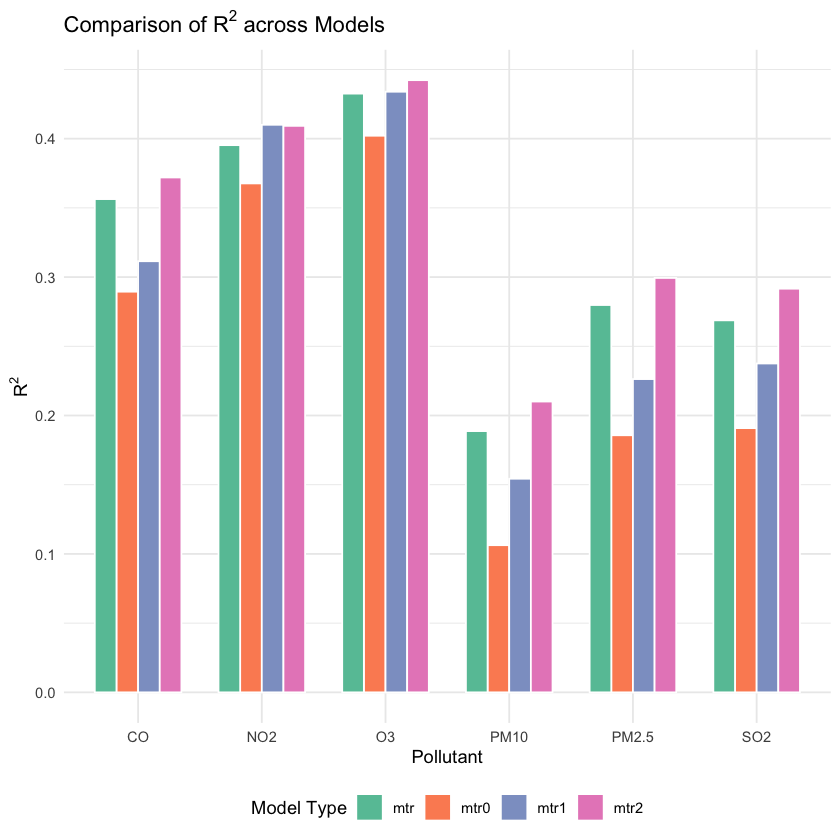

In [6]:
### some simple exploratory testing of different "candidate" models
# plain
mtr0 <- lm(log(cbind(PM2.5, PM10, SO2, NO2, CO, O3)) ~ TEMP + PRES + RAIN + WSPM, data = dat)
# quadratic terms
mtr1 <- lm(log(cbind(PM2.5, PM10, SO2, NO2, CO, O3)) ~ (TEMP + PRES + RAIN + WSPM)^2, data = dat)
# plain +  wind direction
mtr <- lm(log(cbind(PM2.5, PM10, SO2, NO2, CO, O3)) ~ TEMP + PRES + RAIN + WSPM + as.factor(wd_coarse), data = dat)
# final: same as previous, but includes interaction terms
mtr2 <- lm(log(cbind(PM2.5, PM10, SO2, NO2, CO, O3)) ~ TEMP + PRES + RAIN + (WSPM * as.factor(wd_coarse)), data = dat)

# R-squared comparisons (one for each outcome variable and model)

R2_comparison <- tibble(
  Pollutant = c("PM2.5", "PM10", "SO2", "NO2", "CO", "O3"),
  mtr0 = unlist(lapply(summary(mtr0), function(z) z$r.squared)),
  mtr1 = unlist(lapply(summary(mtr1), function(z) z$r.squared)),
  mtr  = unlist(lapply(summary(mtr),  function(z) z$r.squared)),
  mtr2 = unlist(lapply(summary(mtr2), function(z) z$r.squared))
) %>%
  pivot_longer(
    cols = starts_with("mtr"), # Which columns to collapse
    names_to = "Model",        # The name for the new 'category' column
    values_to = "R_squared"    # The name for the new 'data' column
  )

ggplot(R2_comparison, aes(x = Pollutant, y = R_squared, fill = Model)) +
  geom_col(position = "dodge", color = "white", width = 0.7) +
  scale_fill_brewer(palette = "Set2") +
  labs(
    title = expression(paste("Comparison of ", R^2, " across Models")),
    x = "Pollutant",
    y = expression(R^2),
    fill = "Model Type"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")                         

# the model 'mtr2' achieves comparable or even better R^2's than
# the quadratic model (which has significantly more parameters)        

In [7]:
### partition "dat" into three chunks
### --- training
### --- validation: model selection
### --- test: model evaluation
trainix <- seq(from = 1, to = nrow(dat), by = 3)
validix <- seq(from = 2, to = nrow(dat), by = 3)
testix <- seq(from = 3, to = nrow(dat), by = 3)
# training
dat_train <- dat[trainix,]
# validation
dat_valid <- dat[validix,]
# test
dat_test <- dat[testix,]

# Here, we generate design matrices and response vector for the three data subsets (training, validation, testing)
# the function model.matrix is quite useful. 
# It extracts/generates the design matrix ("X") that corresponds to a model formula
Xtrain <- model.matrix(formula(mtr2), data = dat_train)
ytrain  <- subset(log(cbind(dat$PM2.5, dat$PM10, dat$SO2, dat$NO2, dat$CO, dat$O3)), subset = (1:nrow(dat) %in% trainix))
colnames(ytrain) <- c("PM2.5", "PM10", "SO2", "NO2", "CO", "O3")
ntrain <- nrow(ytrain)

Xvalid <- model.matrix(formula(mtr2), data = dat_valid)
yvalid  <- subset(log(cbind(dat$PM2.5, dat$PM10, dat$SO2, dat$NO2, dat$CO, dat$O3)), subset = (1:nrow(dat) %in% validix))
colnames(yvalid) <- c("PM2.5", "PM10", "SO2", "NO2", "CO", "O3")
nvalid <- nrow(yvalid)

Xtest <- model.matrix(formula(mtr2), data = dat_test)
ytest  <- subset(log(cbind(dat$PM2.5, dat$PM10, dat$SO2, dat$NO2, dat$CO, dat$O3)), subset = (1:nrow(dat) %in% testix))
colnames(ytest) <- c("PM2.5", "PM10", "SO2", "NO2", "CO", "O3")
ntest <- nrow(ytest)

q <- ncol(ytrain)
d <- ncol(Xtrain)
# Identity matrix of dimension q
Id_q <- diag(q)

# generate "long" design matrices and "long" response vectors (cf. p. 18 in lecture-05.pdf)
# this is needed to ensure we can run the lasso using the glmnet package (cf. p. 18 in lecture-05.pdf)
Xtrain_long <- matrix(nrow = q * ntrain, ncol = d  * q)
Xvalid_long <- matrix(nrow = q * nvalid, ncol = d  * q)
Xtest_long <- matrix(nrow = q * ntest, ncol = d  * q)
for(i in 1:nrow(Xtrain)){
    Xtrain_long[((i-1)*q + 1):(i*q),] <- kronecker(Xtrain[i,], Id_q)
    Xvalid_long[((i-1)*q + 1):(i*q),] <- kronecker(Xvalid[i,], Id_q)
    Xtest_long[((i-1)*q + 1):(i*q),] <- kronecker(Xtest[i,], Id_q)
}
ytrain_long <- c(t(ytrain))
yvalid_long <- c(t(yvalid))
ytest_long <- c(t(ytest))


# this line compares the coefficients from the matrix representation of the multivariate linear model
# to the coefficients from the long format -- they need to be identical!
#coef(lm(ytrain ~ Xtrain - 1)) - matrix(coef(lm(ytrain_long ~ Xtrain_long - 1)), nrow = d, ncol = q)


# these are the ordinary least regression again -- note that the intercept is already included in 'Xtrain_long'
beta_ols <- coef(lm(ytrain_long ~ Xtrain_long - 1))

#mse_ols <- mean((yvalid_long - Xvalid_long %*% beta_ols)^2)

# baselines to beat: plain OLS and an intercept model (cf. slide 38 in class-04.pdf)
mse_ols <- mean((ytest_long - Xtest_long %*% beta_ols)^2)
mse_intercept <- mean((apply(ytest, MARGIN = 1, STAT = colMeans(ytrain), FUN = "-"))^2)

In [8]:
mse_ols

[1] 0.7586993

,PM2.5,PM10,SO2,NO2,CO,O3
(Intercept),4.337135e+00,4.491804e+00,1.9823090308,4.2482855462,7.2881782019,1.843492e+00
TEMP,-6.932366e-03,-5.006451e-03,-0.0476384053,-0.0151471125,-0.0159424320,5.474069e-02
PRES,5.095343e-05,3.751398e-05,0.0009840802,0.0002522286,0.0001450943,4.766287e-05
RAIN,0.000000e+00,-3.430682e-02,-0.0952634091,-0.0260907232,0.0186141088,0.000000e+00
WSPM,-2.375896e-01,-1.222639e-01,-0.0174240353,-0.2599973983,-0.2233684275,4.446472e-01
as.factor(wd_coarse)1,3.251400e-01,3.374154e-01,0.0040230872,0.1399388450,0.2776259421,-4.351904e-01
as.factor(wd_coarse)2,-5.852758e-02,-1.264368e-01,0.0000000000,0.0000000000,0.0000000000,-1.558920e-01
as.factor(wd_coarse)3,3.027203e-01,2.675028e-01,0.0162009464,0.1023454277,0.2016774940,-4.733052e-01
as.factor(wd_coarse)4,-6.963420e-01,-6.385951e-01,-0.2267420162,-0.2221774494,-0.3953509624,5.595366e-02
as.factor(wd_coarse)5,5.220251e-02,8.430088e-02,0.1309416650,0.0000000000,0.0211854042,3.942290e-01


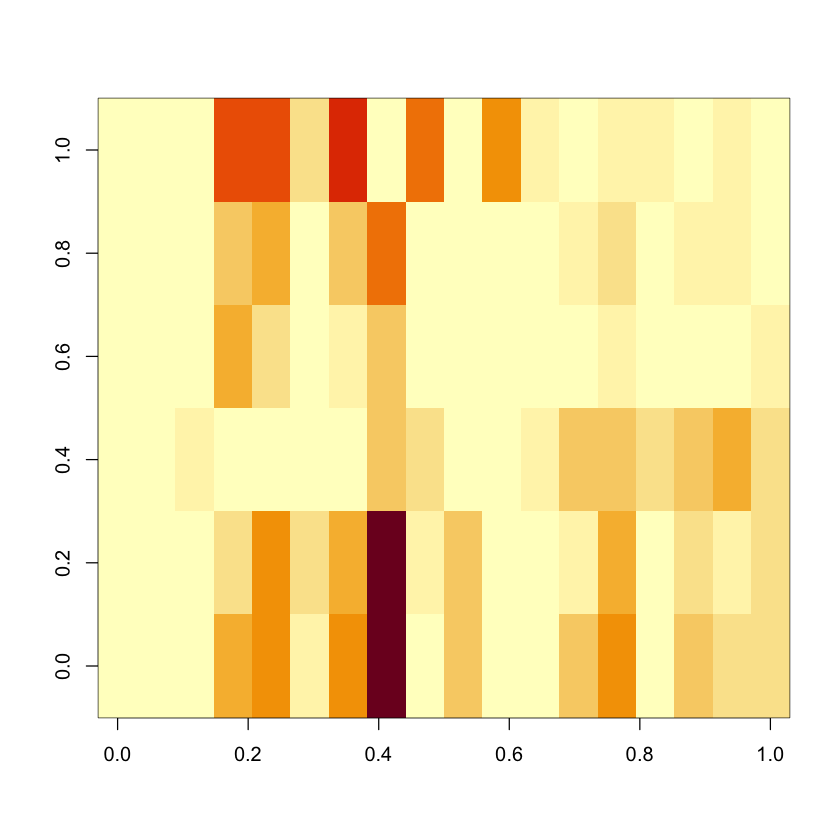

In [9]:
### lasso
# we use the intercepts in Xtrain_long, and do not penalize the corresponding columns
# the glmnet function automatically defines a grid of lambda values and obtains the
# corresponding solutions

lasso_train <- glmnet(x = Xtrain_long, y = ytrain_long, intercept = FALSE,
                      penalty_factor = rep(c(0,rep(1, d- 1)), times = q))

# compute the MSEs on the validation set
mses_valid_lasso <- colMeans((yvalid_long - Xvalid_long %*% lasso_train$beta)^2)
# plot(lasso_train$lambda, mses_valid_lasso) -- we see that the optimal lambda is zero

# compute lasso test error for optimal lambda
lasso_lambdaix <- which.min(mses_valid_lasso)
mses_test_lasso <- mean((ytest_long - Xtest_long %*% lasso_train$beta[,lasso_lambdaix])^2)

# print / visualize the lasso coefficients --- there are indeed some entries exactly equal to zero
Beta_lasso <- matrix(lasso_train$beta[,lasso_lambdaix], nrow = d, ncol = q)
rownames(Beta_lasso) <- colnames(Xtrain)
colnames(Beta_lasso) <- c("PM2.5", "PM10", "SO2", "NO2", "CO", "O3")
image(abs(Beta_lasso[2:d,]))
Beta_lasso

In [10]:
### ridge regression

ridge_train <- glmnet(x = Xtrain_long, y = ytrain_long, intercept = FALSE,
                      penalty_factor = rep(c(0,rep(1, d- 1)), times = q), alpha = 0)

mses_valid_ridge <- colMeans((yvalid_long - Xvalid_long %*% ridge_train$beta)^2)
ridge_lambdaix <- which.min(mses_valid_ridge)
mses_test_ridge <- mean((ytest_long - Xtest_long %*% ridge_train$beta[,ridge_lambdaix])^2)

In [11]:
### group lasso regression

# this may take a few minutes minute or so to run --- this function works with the
# matrix version than with the long version of the data
fit_grpreg <- grpreg(Xtrain[,-1], ytrain, penalty="grLasso",  family= "gaussian",
nlambda=100)

mses_valid_grplasso <- numeric(dim(fit_grpreg$beta)[3])

for(i in 1:dim(fit_grpreg$beta)[3]){
    mses_valid_grplasso[i] <- mean((yvalid - Xvalid %*% t(fit_grpreg$beta[,,i]))^2)
}

# this shows the row sparsity pattern of the solution(s)
t(fit_grpreg$beta[,,10])

# extract test MSE for the value of lamada achieving smallest validation error
grplasso_lambdaix <- which.min(mses_valid_grplasso)
mses_test_grplasso <- mean((ytest - Xtest %*% t(fit_grpreg$beta[,,grplasso_lambdaix]))^2)

(Intercept),4.268397285,4.526522146,2.71482379,4.263376332,7.264370349,2.64965189
TEMP,-0.001224991,-0.001043866,-0.02008299,-0.007709737,-0.007386351,0.02955727
PRES,0.000000000,0.000000000,0.00000000,0.000000000,0.000000000,0.00000000
RAIN,0.000000000,0.000000000,0.00000000,0.000000000,0.000000000,0.00000000
WSPM,-0.191280313,-0.122885294,-0.10221460,-0.168731907,-0.172320333,0.16437638
as.factor(wd_coarse)1,0.053685351,0.035156006,0.02495090,0.023093596,0.048185084,-0.05836573
as.factor(wd_coarse)2,0.000000000,0.000000000,0.00000000,0.000000000,0.000000000,0.00000000
as.factor(wd_coarse)3,0.000000000,0.000000000,0.00000000,0.000000000,0.000000000,0.00000000
as.factor(wd_coarse)4,0.000000000,0.000000000,0.00000000,0.000000000,0.000000000,0.00000000
as.factor(wd_coarse)5,0.000000000,0.000000000,0.00000000,0.000000000,0.000000000,0.00000000
as.factor(wd_coarse)6,0.000000000,0.000000000,0.00000000,0.000000000,0.000000000,0.00000000


In [12]:
### reduced rank regression

# consider the ranks 1 up to 6 for the coeffcient matrix B
rank_grid <- 1:6
errs_valid_rank <- numeric(length(rank_grid))
errs_test_rank <- numeric(length(rank_grid))

# compute validation and test errors for each value of the rank(1 through 6)
for(r in 1:length(rank_grid)){

    Beta_rr <- rrr(Xtrain[,2:d], ytrain, type = "identity", rank = r)
    errs_valid_rank[r] <- mean((sweep(yvalid, MARGIN = 2, STATS = Beta_rr$mean) - Xvalid[,2:d] %*% t(Beta_rr$C))^2)
    errs_test_rank[r] <- mean((sweep(ytest, MARGIN = 2, STATS = Beta_rr$mean) - Xtest[,2:d] %*% t(Beta_rr$C))^2)

}